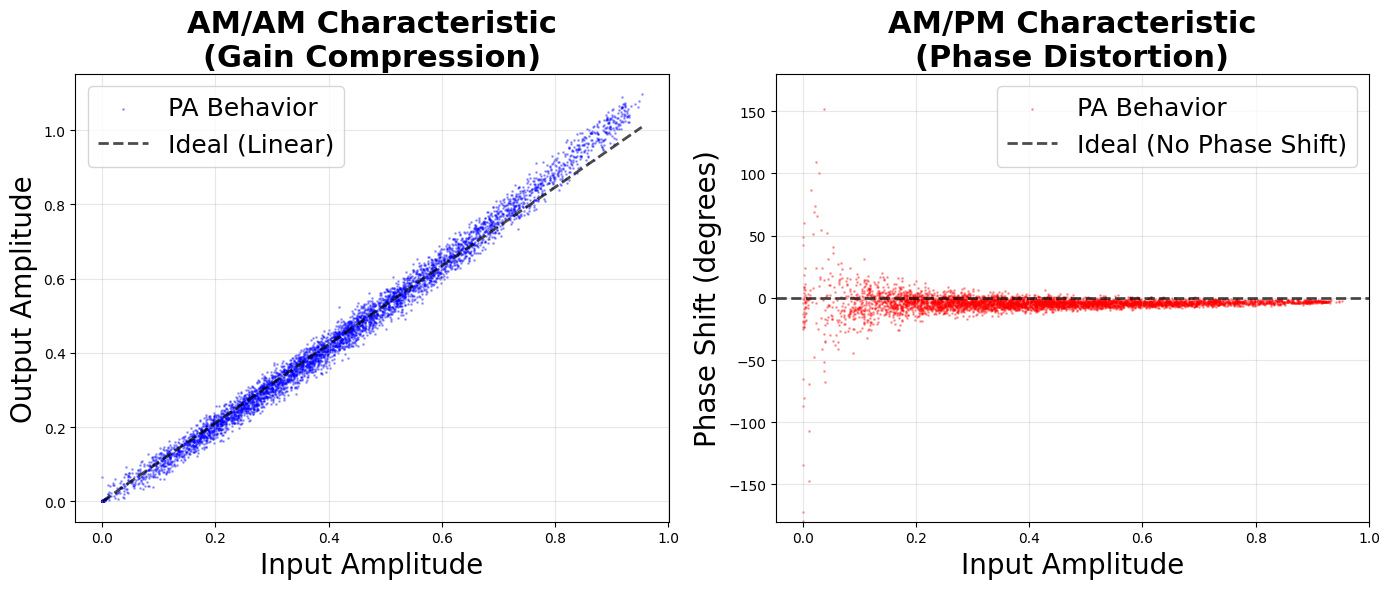


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9528
Output amplitude range: 0.0002 to 1.0967
Estimated small-signal gain: 1.0581
Phase distortion range: -348.67° to 1007.68°
80000


In [ ]:
from sparseDPD import DataManager, PNTDNN_NeuralNetwork, Volterra, LinearExperiment, AdaptivePruningExperiment

# Load the ideal predistorted signal, and plot
ideal_predistored_dataset = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='100M_9.5PAPR.mat')

ideal_predistored_dataset.plot_pa_characteristics()

print(len(ideal_predistored_dataset.input_data))

In [37]:
# Print Volterra Performance
volterra_forward_model = Volterra(num_nl_orders=3, num_memory_levels=15, dataset=ideal_predistored_dataset.training_dataset)

print(f" Volterra NMSE: {volterra_forward_model.calculate_volterra_nmse(ideal_predistored_dataset.test_dataset)} dB")

 Volterra NMSE: -41.42440795829603 dB


In [38]:
# Model the ideal predistorted (This will actually be modelled as a forward model)
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True)

# train this model
pntdnn_ideal_predistorted.get_best_model(
    num_epochs = 500,
    training_dataset=ideal_predistored_dataset.training_dataset,
    validation_dataset=ideal_predistored_dataset.validation_dataset
)

# Save the model, so it can be used later
pntdnn_ideal_predistorted.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model.pt")


Using cuda device
Epoch  10/500  Loss=2.5994e+02  Valid Loss=1.8612e+01  LR=1.00e-03  NMSE=-15.5173 dB
Epoch  20/500  Loss=8.2608e+01  Valid Loss=4.7882e+00  LR=1.00e-03  NMSE=-21.4135 dB
Epoch  30/500  Loss=4.1842e+01  Valid Loss=2.4011e+00  LR=1.00e-03  NMSE=-24.4111 dB
Epoch  40/500  Loss=2.3570e+01  Valid Loss=1.5174e+00  LR=1.00e-03  NMSE=-26.4042 dB
Epoch  50/500  Loss=1.3518e+01  Valid Loss=9.9179e-01  LR=1.00e-03  NMSE=-28.2510 dB
Epoch  60/500  Loss=8.1177e+00  Valid Loss=6.6137e-01  LR=1.00e-03  NMSE=-30.0107 dB
Epoch  70/500  Loss=5.1787e+00  Valid Loss=4.5254e-01  LR=1.00e-03  NMSE=-31.6586 dB
Epoch  80/500  Loss=3.5064e+00  Valid Loss=3.1835e-01  LR=1.00e-03  NMSE=-33.1861 dB
Epoch  90/500  Loss=2.5499e+00  Valid Loss=2.3069e-01  LR=1.00e-03  NMSE=-34.5849 dB
Epoch 100/500  Loss=2.0132e+00  Valid Loss=1.8338e-01  LR=1.00e-03  NMSE=-35.5817 dB
Epoch 110/500  Loss=1.6726e+00  Valid Loss=1.5593e-01  LR=1.00e-03  NMSE=-36.2858 dB
Epoch 120/500  Loss=1.4381e+00  Valid Loss=1.36

Using cuda device

Pruning Iteration 1/10
Pruning 20.0% of remaining weights...
Current pruning: 20.00% of weights are zero
Retraining for 100 epochs...
Epoch  10/100  Loss=3.0338e-01  Valid Loss=2.6354e-02  LR=1.00e-03  NMSE=-44.0067 dB
Epoch  20/100  Loss=2.6758e-01  Valid Loss=2.3120e-02  LR=5.00e-04  NMSE=-44.5753 dB
Epoch  30/100  Loss=2.6372e-01  Valid Loss=2.2913e-02  LR=5.00e-04  NMSE=-44.6144 dB
Epoch  40/100  Loss=2.6694e-01  Valid Loss=2.3039e-02  LR=5.00e-04  NMSE=-44.5905 dB
Epoch  50/100  Loss=2.9956e-01  Valid Loss=2.2079e-02  LR=2.50e-04  NMSE=-44.7754 dB
Epoch  60/100  Loss=2.5264e-01  Valid Loss=2.5921e-02  LR=1.25e-04  NMSE=-44.0787 dB
Epoch  70/100  Loss=2.4371e-01  Valid Loss=2.4012e-02  LR=6.25e-05  NMSE=-44.4109 dB
Epoch  80/100  Loss=2.4177e-01  Valid Loss=2.3587e-02  LR=3.13e-05  NMSE=-44.4885 dB
Epoch  90/100  Loss=2.4091e-01  Valid Loss=2.3343e-02  LR=1.56e-05  NMSE=-44.5336 dB
Epoch 100/100  Loss=2.4041e-01  Valid Loss=2.3344e-02  LR=7.81e-06  NMSE=-44.5334 

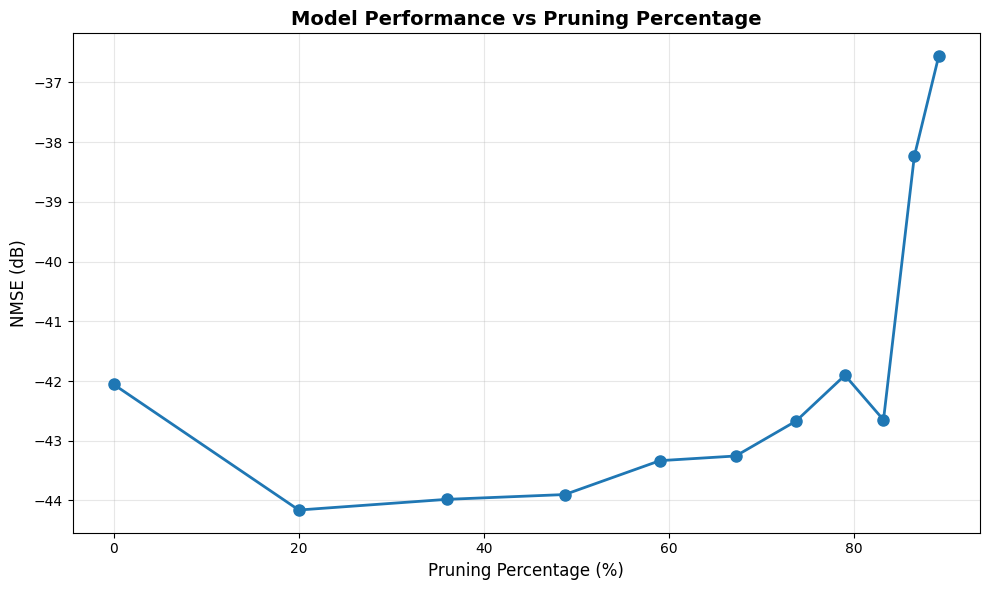

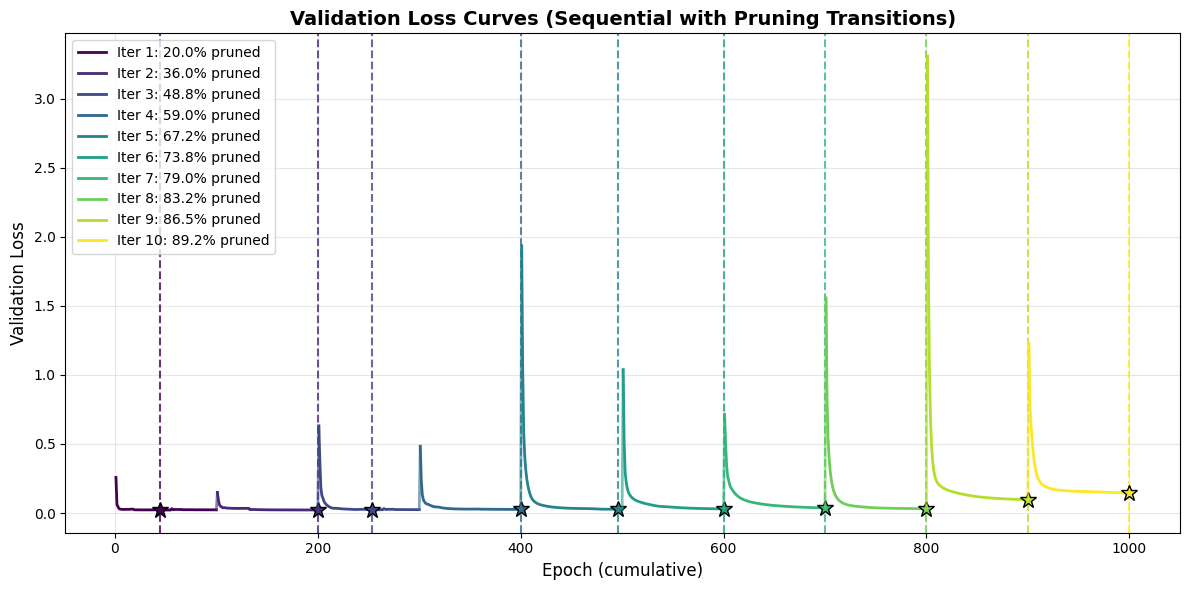

In [39]:
# Linearly prune the model
# Load the model
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

pntdnn_ideal_pruning_experiment = LinearExperiment(
    nn_model= pntdnn_ideal_predistorted,
    num_prune_iterations=10,
    prune_amount=0.2,
    retrain_epochs=100,
    training_dataset=ideal_predistored_dataset.training_dataset,
    valid_dataset=ideal_predistored_dataset.validation_dataset,
    test_dataset=ideal_predistored_dataset.test_dataset,
    nmse_tolerance=-37
)
pntdnn_ideal_pruning_experiment.run()

# Save the best model
pntdnn_ideal_pruning_experiment.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")

Using cuda device
Baseline NMSE          : -42.0576 dB
Tolerance              : +5.06 dB
NMSE must stay below   : -37.0000 dB
Initial prune fraction : 50.0%
Min prune fraction     : 1.0%
Max prune fraction     : 50.0%

Step 1  |  fraction = 50.00%
Pruning 50.00% of remaining weights...
Current sparsity: 50.00% of weights are zero
Retraining for 200 epochs...
Epoch  10/200  Loss=1.1120e+00  Valid Loss=1.0312e-01  LR=1.00e-03  NMSE=-38.0816 dB
Epoch  20/200  Loss=6.5253e-01  Valid Loss=6.0665e-02  LR=1.00e-03  NMSE=-40.3858 dB
Epoch  30/200  Loss=5.2877e-01  Valid Loss=4.1000e-02  LR=1.00e-03  NMSE=-42.0873 dB
Epoch  40/200  Loss=4.4319e-01  Valid Loss=3.8127e-02  LR=1.00e-03  NMSE=-42.4028 dB
Epoch  50/200  Loss=3.9295e-01  Valid Loss=3.3925e-02  LR=1.00e-03  NMSE=-42.9100 dB
Epoch  60/200  Loss=3.7788e-01  Valid Loss=3.1284e-02  LR=1.00e-03  NMSE=-43.2619 dB
Epoch  70/200  Loss=3.7183e-01  Valid Loss=3.1373e-02  LR=1.00e-03  NMSE=-43.2496 dB
Epoch  80/200  Loss=3.6157e-01  Valid Loss=3

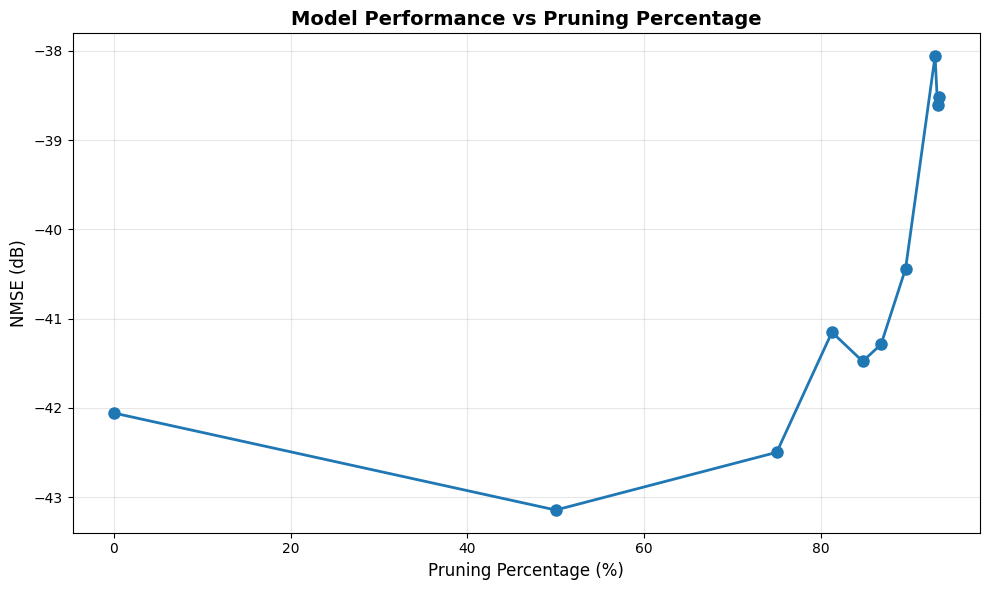

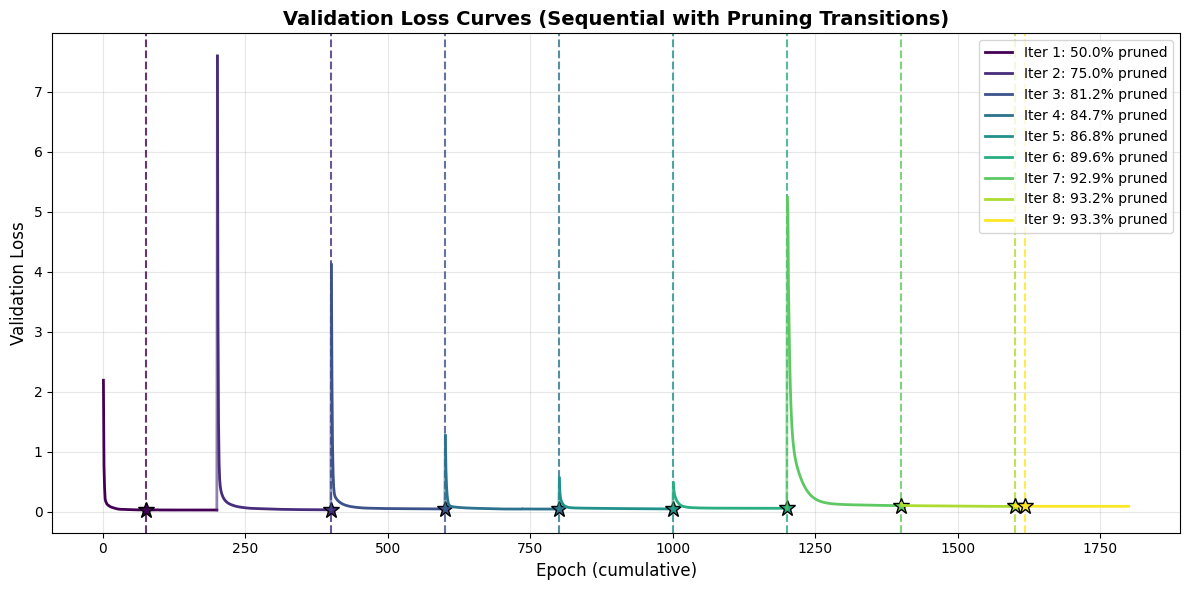

In [41]:
# Use adaptive pruning
pntdnn_ideal_predistorted = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

adaptive_pruning_experiment_PNTDNN = AdaptivePruningExperiment(
    nn_model=pntdnn_ideal_predistorted,
    retrain_epochs= 200,
    training_dataset = ideal_predistored_dataset.training_dataset,
    valid_dataset = ideal_predistored_dataset.validation_dataset,
    test_dataset = ideal_predistored_dataset.test_dataset,
    nmse_threshold = -37,
    initial_prune_fraction=0.5,
    min_prune_fraction=0.01,
    max_prune_fraction=0.5
)

adaptive_pruning_experiment_PNTDNN.run()

# Save the best model
adaptive_pruning_experiment_PNTDNN.best_model.write_nn_to_file(file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")

In [42]:
# make .mat files for the best models, so they can be used in the future for physical testing
import scipy.io

num_memory_levels = 15
# Load original, adaptive and fixed pruning models
adaptive_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_adaptive_pruned.pt")
fixed_percent_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model_linear_pruned.pt")
original_model = PNTDNN_NeuralNetwork(num_memory_levels=15, model_type="OneLayerNetwork", forward_model=True, nn_file_path="pntdnn_ideal_predistorted_forward_model.pt")

# Get the full input signal
full_input = ideal_predistored_dataset.input_data

# Generate outputs for each model
print("Generating outputs for each model...")
adaptive_output = adaptive_model.generate_model_output(full_input)
fixed_output = fixed_percent_model.generate_model_output(full_input)
original_output = original_model.generate_model_output(full_input)

# Save to .mat files with 'x' (input) and 'u' (output) naming convention
print("Saving .mat files...")
scipy.io.savemat('adaptive_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': adaptive_output})
scipy.io.savemat('fixed_pruned_output.mat', {'x1': full_input[num_memory_levels:], 'u': fixed_output})
scipy.io.savemat('original_model_output.mat', {'x1': full_input[num_memory_levels:], 'u': original_output})

print("✓ Saved adaptive_pruned_output.mat")
print("✓ Saved fixed_pruned_output.mat")
print("✓ Saved original_model_output.mat")

Using cuda device
Using cuda device
Using cuda device
Generating outputs for each model...
Saving .mat files...
✓ Saved adaptive_pruned_output.mat
✓ Saved fixed_pruned_output.mat
✓ Saved original_model_output.mat


In [ ]:
# Optionally save Volterra model output as well
volterra_output = volterra_forward_model.generate_model_output(full_input)
scipy.io.savemat('volterra_output.mat', {'x1': full_input[num_memory_levels:], 'u': volterra_output})
print("✓ Saved volterra_output.mat")

✓ Saved volterra_output.mat


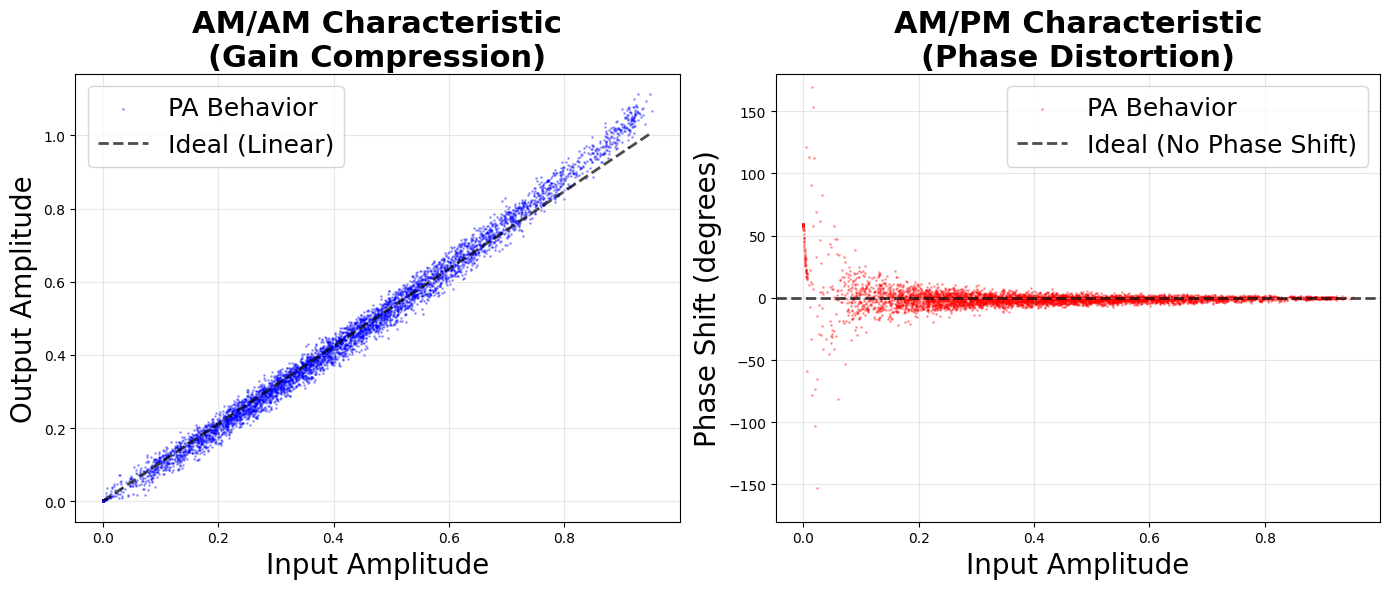


=== PA Characteristic Summary ===
Input amplitude range: 0.0000 to 0.9520
Output amplitude range: 0.0024 to 1.1121
Estimated small-signal gain: 1.0588
Phase distortion range: -152.59° to 169.79°


In [43]:
test = DataManager(num_training_points=50000, num_test_points=5000, num_validaiton_points=5000, filepath='fixed_pruned_output.mat')

test.plot_pa_characteristics()